# W validation — GLORYS vs `Fix_W.ipynb` vs the finite-volume reconstruction

Standalone: it rebuilds W for one day from U and V, so it does not need the output of
`Fix_W_v3.ipynb` to exist.

Two questions:

1. **Does the reconstruction reproduce GLORYS' own `vovecrtz`?** If yes, the finite-volume
   budget is right and can be defended.
2. **Which combination of (U, V, W) is actually consistent on the vertical axis Parcels
   integrates on?** This is the one that decides whether particles accumulate.

In [1]:
YEAR, MONTH, DAY = 1993, 1, 2          # day index into the monthly file (1-based)

MESH   = "Zgr_cmesh2.nc"
U_PATH = f"U_{YEAR}-{MONTH:02d}.nc"
V_PATH = f"V_{YEAR}-{MONTH:02d}.nc"
W_PATH = f"W_{YEAR}-{MONTH:02d}.nc"          # GLORYS, as delivered
W_OLD  = f"W_{YEAR}-{MONTH:02d}fc.nc"        # output of Fix_W.ipynb  (set to None to skip)

POINTS = {"shelf": (138, 564),               # (j, i) in the local index space of the cut-out
          "deep":  (250, 600)}

STATS_BOX = dict(y=slice(120, 320), x=slice(400, 700))   # interior box for the residual table
FIGURE    = "W_profiles_comparison.png"

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

T = DAY - 1

## 1. Mesh: thicknesses and horizontal metrics

In [3]:
mesh = xr.open_dataset(MESH).squeeze()
mb   = mesh.mbathy.values.astype(int)
gdepw_0 = mesh.gdepw_0.squeeze().values.astype("f8")     # nominal w-levels (Parcels' axis)
gdept_0 = mesh.gdept_0.squeeze().values.astype("f8")     # nominal T-levels (U, V axis)
nz = gdepw_0.size
k  = np.arange(nz)[:, None, None]

e3t_partial = np.where(k + 1 <= mb - 1, mesh.e3t_0.squeeze().values[:, None, None],
                       mesh.e3t_ps.values)
e3t_partial = np.where(k + 1 <= mb, e3t_partial, 0.0)                       # NEMO's grid
e3t_nominal = np.where(k + 1 <= mb,
                       mesh.e3t_0.squeeze().values[:, None, None], 0.0) \
              * np.ones_like(mb)                                            # Parcels' grid

R = 6371229.0
def _hav(lo1, la1, lo2, la2):
    p = np.pi / 180.0
    a = np.sin((la2 - la1) * p / 2) ** 2 + np.cos(la1 * p) * np.cos(la2 * p) \
        * np.sin((lo2 - lo1) * p / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

lon = mesh.nav_lon.values.astype("f8"); lat = mesh.nav_lat.values.astype("f8")
e1u = np.empty_like(lon); e2v = np.empty_like(lon)
e1u[:, :-1] = _hav(lon[:, :-1], lat[:, :-1], lon[:, 1:], lat[:, 1:]); e1u[:, -1] = e1u[:, -2]
e2v[:-1, :] = _hav(lon[:-1, :], lat[:-1, :], lon[1:, :], lat[1:, :]); e2v[-1, :] = e2v[-2, :]
e1t = np.empty_like(e1u); e1t[:, 1:] = 0.5 * (e1u[:, :-1] + e1u[:, 1:]); e1t[:, 0] = e1u[:, 0]
e2t = np.empty_like(e2v); e2t[1:, :] = 0.5 * (e2v[:-1, :] + e2v[1:, :]); e2t[0, :] = e2v[0, :]
e2u, e1v, area = e2t, e1t, e1t * e2t

def face(e3, axis):
    f = np.minimum(e3, np.roll(e3, -1, axis=axis))
    if axis == 2: f[:, :, -1] = e3[:, :, -1]
    else:         f[:, -1, :] = e3[:, -1, :]
    return f

e3u_n, e3v_n = face(e3t_nominal, 2), face(e3t_nominal, 1)
ru = np.divide(face(e3t_partial, 2), e3u_n, out=np.zeros_like(e3u_n), where=e3u_n > 0)
rv = np.divide(face(e3t_partial, 1), e3v_n, out=np.zeros_like(e3v_n), where=e3v_n > 0)
print(f"{nz} levels, {int((mb>0).sum())} ocean columns")

50 levels, 425361 ocean columns


## 2. One day of U, V, W

In [4]:
u  = np.nan_to_num(xr.open_dataset(U_PATH).vozocrtx.isel(time_counter=T).values).astype("f8")
v  = np.nan_to_num(xr.open_dataset(V_PATH).vomecrty.isel(time_counter=T).values).astype("f8")
wG = np.nan_to_num(xr.open_dataset(W_PATH).vovecrtz.isel(time_counter=T).values).astype("f8")
wO = (np.nan_to_num(xr.open_dataset(W_OLD).vovecrtz.isel(time_counter=T).values).astype("f8")
      if W_OLD else None)

uc, vc = u * ru, v * rv                    # partial-cell-weighted, for Parcels' nominal grid

/Users/dlizarbe/micromamba/envs/parcels-dev/lib/python3.12/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'vozocrtx' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/dlizarbe/micromamba/envs/parcels-dev/lib/python3.12/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'vomecrty' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/dlizarbe/micromamba/envs/parcels-dev/lib/python3.12/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'vovecrtz' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


## 3. Reconstruct W

Volume budget for T-cell $k$, $w_k$ on its **top** face, integrated upward from $w=0$ at the
seabed:

$$w_k A = w_{k+1} A - \big(F^u_i - F^u_{i-1} + F^v_j - F^v_{j-1}\big)_k$$

In [5]:
def reconstruct_w(u, v, e3u, e3v):
    Fu, Fv = u * e2u * e3u, v * e1v * e3v          # m3/s through each face
    div = np.zeros_like(Fu)
    div[:, :, 1:]  = Fu[:, :, 1:] - Fu[:, :, :-1]; div[:, :, 0] = np.nan
    div[:, 1:, :] += Fv[:, 1:, :] - Fv[:, :-1, :]; div[:, 0, :] = np.nan
    return np.cumsum((-div / area)[::-1], axis=0)[::-1]

wR = reconstruct_w(uc, vc, e3u_n, e3v_n)           # == reconstruct_w(u, v, e3_partial)

### Q1 — does it reproduce GLORYS?

Nothing here has seen `vovecrtz`; W comes only from U, V and the mesh.

In [6]:
sb = (slice(None), STATS_BOX["y"], STATS_BOX["x"])
g  = (e3t_partial[sb] > 0)
print(f"corr(reconstructed, GLORYS)  {np.corrcoef(wR[sb][g], wG[sb][g])[0,1]:.4f}")
print(f"rms difference               {np.sqrt(((wR[sb][g]-wG[sb][g])**2).mean()):.2e} m/s")
print(f"rms |W|                      {np.sqrt((wG[sb][g]**2).mean()):.2e} m/s")
print(f"-> {np.sqrt(((wR[sb][g]-wG[sb][g])**2).mean())/np.sqrt((wG[sb][g]**2).mean()):.2%} "
      "of the signal, which is the error of the approximated horizontal metrics")

corr(reconstructed, GLORYS)  1.0000
rms difference               2.78e-07 m/s
rms |W|                      9.91e-05 m/s
-> 0.28% of the signal, which is the error of the approximated horizontal metrics


### Q2 — which triple is consistent on Parcels' axis?

For every cell, $\;r_k = \dfrac{\nabla\!\cdot\!F_k}{A} + (w_k - w_{k+1})\;$ using the **nominal**
thicknesses, i.e. exactly the budget Parcels' C-grid interpolation implies. $r=0$ means a
particle can neither be created nor destroyed by the discrete flow; $r \neq 0$ is a source or
sink that particles pile into.

In [7]:
def residual(u, v, w, label):
    Fu, Fv = u * e2u * e3u_n, v * e1v * e3v_n
    div = np.zeros_like(Fu)
    div[:, :, 1:]  = Fu[:, :, 1:] - Fu[:, :, :-1]
    div[:, 1:, :] += Fv[:, 1:, :] - Fv[:, :-1, :]
    wl = np.concatenate([w, np.zeros((1,) + w.shape[1:])], 0)
    r = div / area + (wl[:-1] - wl[1:])
    val = np.sqrt(np.nanmean(r[sb] ** 2))
    print(f"  {label:<44s} {val:.2e}")
    return val

wRs = wR.copy(); wRs[0] = 0.0                      # surface residual removed
print(f"  {'rms |W| for scale':<44s} {np.sqrt((wG[sb][g]**2).mean()):.2e}\n")
print("  rms divergence residual [m/s per cell]")
residual(u,  v,  wG,  "(a) raw U,V        + GLORYS W")
if wO is not None:
    residual(u, v, wO, "(b) raw U,V        + Fix_W.ipynb W")
residual(uc, vc, wG,  "(c) rescaled U,V   + GLORYS W")
residual(uc, vc, wR,  "(d) rescaled U,V   + reconstructed W")
residual(uc, vc, wRs, "(e) rescaled U,V   + reconstructed W, surface zeroed");

  rms |W| for scale                            9.91e-05

  rms divergence residual [m/s per cell]
  (a) raw U,V        + GLORYS W                1.38e-04
  (b) raw U,V        + Fix_W.ipynb W           1.38e-04
  (c) rescaled U,V   + GLORYS W                1.76e-08
  (d) rescaled U,V   + reconstructed W         3.62e-21
  (e) rescaled U,V   + reconstructed W, surface zeroed 6.01e-08


**How to read the table.** (a) and (b) are indistinguishable — the old compensation does not
change the consistency of the field at all, which is why the particles behaved the same. The
jump happens at (c), and it comes entirely from rescaling U and V.

(c) and (d) are both tiny. (d) is exactly zero by construction, but it depends on the
approximated metrics; (c) keeps GLORYS' own W untouched and is only limited by those same
metrics entering the flux term. **(c) is the easier one to defend and the one to ship** — see
`W_SOURCE` in `Fix_W_v3.ipynb`. (e) is (d) with the free-surface signal removed from the top
cell, which buys a fixed sea surface at the cost of a residual in level 0 only.

## 4. Profiles

saved W_profiles_comparison.png


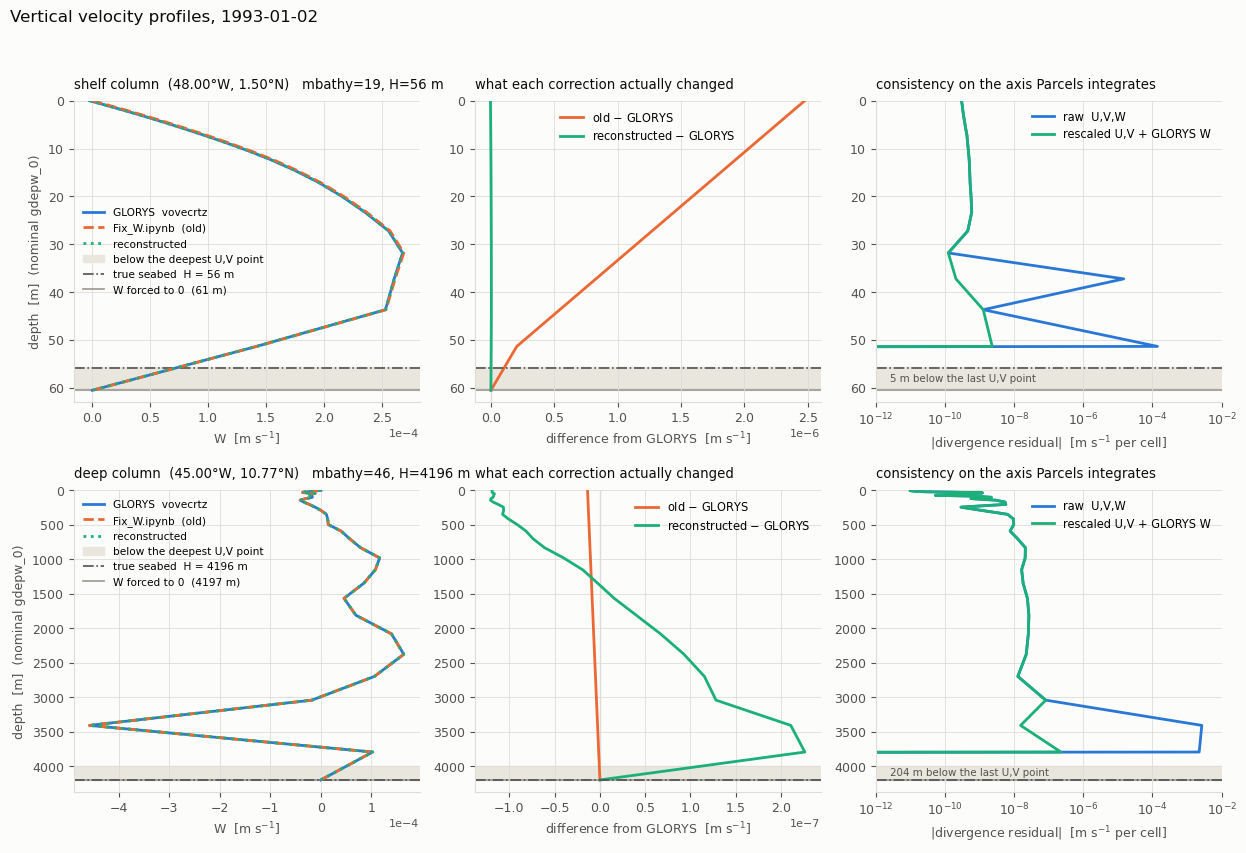

In [8]:
SURF, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#dedcd6"
C_G, C_O, C_R = "#2a78d6", "#eb6834", "#1baf7a"          # GLORYS / old / reconstructed
plt.rcParams.update({"font.size": 9, "axes.edgecolor": GRID, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2, "axes.facecolor": SURF,
    "figure.facecolor": SURF, "axes.titlecolor": INK})

nrow = len(POINTS)
fig, axs = plt.subplots(nrow, 3, figsize=(12.5, 4.3 * nrow), squeeze=False)

for r, (name, (j, i)) in enumerate(POINTS.items()):
    m = mb[j, i]; H = e3t_partial[:, j, i].sum()
    n = min(m + 1, nz); z = gdepw_0[:n]
    zw0, ztop = gdepw_0[min(m, nz - 1)], gdept_0[m - 1]

    ax = axs[r, 0]
    ax.plot(wG[:n, j, i], z, lw=2, color=C_G, label="GLORYS  vovecrtz", zorder=3)
    if wO is not None:
        ax.plot(wO[:n, j, i], z, lw=2, ls="--", color=C_O, label="Fix_W.ipynb  (old)", zorder=4)
    ax.plot(wR[:n, j, i], z, lw=2, ls=":", color=C_R, label="reconstructed", zorder=5)
    ax.set_xlabel("W  [m s$^{-1}$]")
    ax.set_title(f"{name} column  ({abs(lon[j,i]):.2f}°W, {lat[j,i]:.2f}°N)   "
                 f"mbathy={m}, H={H:.0f} m", loc="left", fontsize=9.5, pad=9)

    ax = axs[r, 1]
    if wO is not None:
        ax.plot(wO[:n, j, i] - wG[:n, j, i], z, lw=2, color=C_O, label="old $-$ GLORYS")
    ax.plot(wR[:n, j, i] - wG[:n, j, i], z, lw=2, color=C_R, label="reconstructed $-$ GLORYS")
    ax.axvline(0, lw=1, color=GRID, zorder=1)
    ax.set_xlabel("difference from GLORYS  [m s$^{-1}$]")
    ax.set_title("what each correction actually changed", loc="left", fontsize=9.5, pad=9)

    ax = axs[r, 2]
    def rprof(uu, vv, ww):
        Fu, Fv = uu * e2u * e3u_n, vv * e1v * e3v_n
        d = np.zeros_like(Fu)
        d[:, :, 1:]  = Fu[:, :, 1:] - Fu[:, :, :-1]
        d[:, 1:, :] += Fv[:, 1:, :] - Fv[:, :-1, :]
        wl = np.concatenate([ww, np.zeros((1,) + ww.shape[1:])], 0)
        return np.abs((d / area + (wl[:-1] - wl[1:]))[:n, j, i])
    ax.plot(rprof(u, v, wG),   z, lw=2, color=C_G, label="raw  U,V,W")
    ax.plot(rprof(uc, vc, wG), z, lw=2, color=C_R, label="rescaled U,V + GLORYS W")
    ax.set_xscale("log"); ax.set_xlim(1e-12, 1e-2)
    ax.set_xlabel("|divergence residual|  [m s$^{-1}$ per cell]")
    ax.set_title("consistency on the axis Parcels integrates", loc="left", fontsize=9.5, pad=9)
    ax.annotate(f"{zw0-ztop:.0f} m below the last U,V point", (0.04, (ztop + zw0) / 2),
                xycoords=("axes fraction", "data"), fontsize=7.4, color=INK2, va="center")

    for c, ax in enumerate(axs[r]):
        ax.axhspan(ztop, zw0, color="#e9e6dd", zorder=0,
                   label="below the deepest U,V point" if c == 0 else None)
        ax.axhline(H, lw=1.2, color=INK2, ls="-.", zorder=2,
                   label=f"true seabed  H = {H:.0f} m" if c == 0 else None)
        ax.axhline(zw0, lw=1.2, color="#9b9891", zorder=1,
                   label=f"W forced to 0  ({zw0:.0f} m)" if c == 0 else None)
        ax.set_ylim(0, zw0 * 1.04); ax.invert_yaxis()
        ax.grid(True, lw=0.6, color=GRID, zorder=0)
        for s in ("top", "right"): ax.spines[s].set_visible(False)
        if c == 0: ax.set_ylabel("depth  [m]  (nominal gdepw_0)")
        if c != 2:
            ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
            ax.xaxis.get_offset_text().set(color=INK2, size=8)
        ax.legend(frameon=False, fontsize=7.6 if c == 0 else 8.2, loc="best")

fig.suptitle(f"Vertical velocity profiles, {YEAR}-{MONTH:02d}-{DAY:02d}",
             x=0.008, ha="left", fontsize=12, color=INK, y=0.985)
fig.tight_layout(rect=[0, 0, 1, 0.955])
fig.savefig(FIGURE, dpi=170, facecolor=SURF)
print("saved", FIGURE)

---

**What the figure shows.** Left: the three W fields lie on top of each other — neither
correction changes W in any way you can see. Middle: the old compensation is a linear taper
that goes to zero at the seabed, ~2.5e-6 m/s on the shelf and ~1e-8 m/s in the deep column;
the reconstruction departs from GLORYS only by the error of the approximated metrics.
Right: the raw triple is inconsistent by more than the magnitude of W itself, and rescaling
U and V removes essentially all of it. The shaded band is the gap between the deepest U,V
point and the level where W is pinned to zero — 5 m on the shelf, 204 m in the deep column.